# Exploratory Data Analysis Model 1 (Delay Predictor)

Dataset ini diperoleh dari https://www.kaggle.com/datasets/rasyidstat/transjakarta-bus-gps-data yang merupakan sample data GPS Bus Transjakarta pada tanggal 26 November 2019 pukul 14.00-18.00 dengan interval sekitar 30 detik. Credit for Rasyid Ridha

## Dataset Understanding

In [1]:
import pandas as pd
df = pd.read_csv('../data/transjakarta_gps.csv')
df.sample(5)

,bus_code,trip_id,gps_datetime,location,dtd,corridor,longitude,latitude,speed,course,color
323658,PPD 0315,9.B002,2019-11-26 15:28:48,NaN,0.000000,1,106.836189,-6.241050,30.0,106,BIRU KOMBINASI
486610,SAF 045,11.004,2019-11-26 17:52:19,"11-9,11-8",0.070353,11,106.898553,-6.213482,6.6,82,BIRU PUTIH
281008,PPD 0212,S22.006,2019-11-26 16:37:09,NaN,0.000000,S22,106.874313,-6.308140,13.0,258,BIRU KOMBINASI
561351,TJ 0267,1.002,2019-11-26 16:58:06,"1-15,1-14",0.991430,1,106.822955,-6.176225,9.9,172,MERAH MUDA
67407,KAJ 142,9.E005,2019-11-26 17:03:35,NaN,0.000000,9E,106.795300,-6.214300,34.0,45,BIRU PUTIH


**Insight**:

Penjelasan setiap kolom dataset
- **bus_code** : merupakan kode bus transjakarta seperti DMR 5049 yang merupakan bus gandeng bermerk Zhongtong yang dioperasikan oleh DAMRI untuk TJ
- **trip_id** : merupakan id perjalanan bus dengan format [koridor].[sequence] 
- **gps_datetime** : merupakan timestamp GPS dalam format GMT+07
- **location** : merupakan kode tag lokasi dari bus
- **dtd** : merupakan distance to destination yakni jarak bus menuju tujuannya dalam kilometer yang dinormalisasi dalam rentang 0-1
- **longitude**: merupakan posisi bujur bus
- **latitude**: merupakan posisi lintang bus
- **course**: merupakan arah mata angin ke mana bus menghadap dalam rentang 0-360 derajat
- **color**: merupakan warna bus

In [2]:
df.shape

(775458, 11)

**Insight**:

Dataset memiliki 775.458 baris dengan 11 kolom

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 775458 entries, 0 to 775457
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   bus_code      775458 non-null  str    
 1   trip_id       773791 non-null  str    
 2   gps_datetime  775458 non-null  str    
 3   location      234477 non-null  str    
 4   dtd           775458 non-null  float64
 5   corridor      775458 non-null  str    
 6   longitude     775458 non-null  float64
 7   latitude      775458 non-null  float64
 8   speed         775458 non-null  float64
 9   course        775458 non-null  int64  
 10  color         663910 non-null  str    
dtypes: float64(4), int64(1), str(6)
memory usage: 65.1 MB


**Insight**:

Semua tipe data tidak ada masalah untuk sementara, tetapi nanti gps_datetime harus diubah ke datetime bukan string. Ditambah beberapa kolom terdapat data yang kosong yakni pada trip_id, location, dan color

In [5]:
df.isna().sum()

bus_code             0
trip_id           1667
gps_datetime         0
location        540981
dtd                  0
corridor             0
longitude            0
latitude             0
speed                0
course               0
color           111548
dtype: int64

**Insight**:

Terdapat data yang kosong pada trip_id sebanyak 1667, location sebanyak 540.981, dan color sebanyak 111.548

## Statistical Analysis

In [4]:
df.describe()

,dtd,longitude,latitude,speed,course
count,775458.000000,775458.000000,775458.000000,775458.000000,775458.000000
mean,0.162886,106.834711,-6.219048,10.669549,184.804686
std,0.303771,0.062049,0.056854,14.843973,104.897736
min,0.000000,106.607000,-6.791528,0.000000,0.000000
25%,0.000000,106.800682,-6.252425,0.000000,92.000000
50%,0.000000,106.830993,-6.214215,1.900000,183.000000
75%,0.137812,106.874008,-6.177220,19.000000,272.000000
max,1.000000,108.330973,-6.048802,309.000000,360.000000


**Insight**:

Beberapa ada yang janggal seperti nilai maksimal speed yang melebihi 50-80 km/j (maksimal dalam aturan operasional TJ) yakni 309 km/j (mobil F1 kah ini?). Nilai posisi GPS juga melebihi wilayah operasional TJ, seperti longitude yang mencapai 108.3 (sudah masuk sekitar cirebon, majalengka, kuningan, hingga tegal) dan latitude mencapai -6.04 sekitar ujung PIK.

In [6]:
print((df["dtd"] == 0).sum())
print((df["dtd"] == 0).value_counts(normalize=True))

528378
dtd
True     0.681375
False    0.318625
Name: proportion, dtype: float64


In [7]:
# Berapa baris dtd=0 yang punya location terisi?
mask = (df['dtd'] == 0) & (df['location'].notna())
print(mask.sum())
print(df[mask][['speed', 'location', 'dtd']].head(10))

0
Empty DataFrame
Columns: [speed, location, dtd]
Index: []


**Insight**:

Sesuai hasil describe sebelumnya, nilai dtd didominasi oleh nilai 0 sebanyak 528.378 baris atau sekitar 68% dari total baris. Artinya mayoritas data adalah bus yang sedang diam di halte atau belum masuk segmen aktif. 
Beberapa kemungkinan:
- Bus sedang berhenti di halte (normal)
- GPS belum lock segmen (data artifact)
- Bus di terminal awal sebelum berangkat

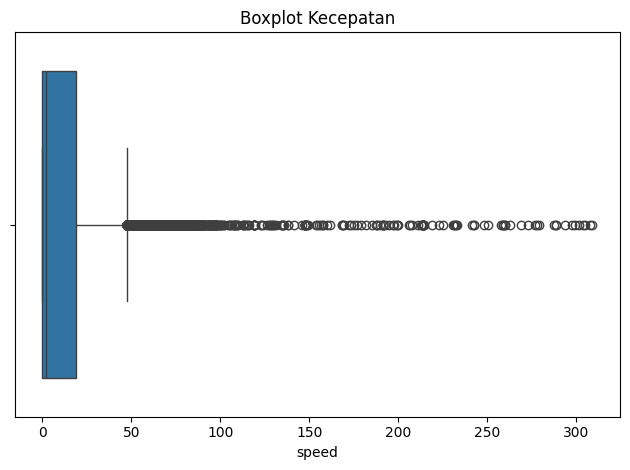

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["speed"])

plt.title('Boxplot Kecepatan')
plt.tight_layout()
plt.show()

**Insight**:

Sesuai dengan hasil describe sebelumnya, persebaran data dari Q1-Q3 menumpuk di rentang 0-19. Ini menunjukkan bahwa sebagian besar waktu operasional bus dihabiskan dalam kondisi diam (statis) atau merayap sangat lambat. Kemudian mulai dari 48 hingga menembus 300, terdapat sebaran outlier yang sangat banyak. Ada dua kemungkinan:

Untuk rentang 50 - 80 masih merupakan outlier yang valid secara fisik. Bus Transjakarta yang melewati jalur layang koridor 13 (Ciledug - Tendean) atau saat kondisi sepi sangat mungkin melaju hingga kecepatan 60–80 km/jam.

Kalau untuk rentang > 100 sampai 309, ini baru ada yang salah dan kemungkinannya glitch GPS. Karakteristik bus memiliki speed limiter yang biasanya dikunci di angka 50–60 km/jam demi keselamatan. Angka di atas 100 hingga mendekati 310 adalah kegagalan sensor GPS dalam menghitung anomali jarak antar-log waktu (ping interval).


## Data Cleaning

### Over Speed Anomaly

In [19]:
over_speed = df[df["speed"] >= 80]
df_clean_over_speed = df[~(df["speed"] >= 80)].copy()
print(over_speed.shape[0])
print(df_clean_over_speed.shape[0])
df_clean_over_speed.sample(10)

357
775101


,bus_code,trip_id,gps_datetime,location,dtd,corridor,longitude,latitude,speed,course,color
335087,PPD 0341,4.001,2019-11-26 16:33:38,"4-14,4-13",0.918331,4,106.853508,-6.199610,0.0,50,BIRU KOMBINASI
609837,TJ 0474,13.010,2019-11-26 14:39:47,NaN,0.000000,13,106.719872,-6.228415,11.3,125,NaN
345120,PPD 0366,6.M002,2019-11-26 17:24:49,NaN,0.000000,4,106.828018,-6.240000,0.0,100,BIRU KOMBINASI
164439,MYS 17066,5.K002,2019-11-26 17:36:46,NaN,0.000000,5,106.825358,-6.136367,28.9,261,BIRU
298760,PPD 0253,2.B004,2019-11-26 17:46:18,NaN,0.000000,2,106.948807,-6.185260,0.0,97,BIRU KOMBINASI
200868,MYS 18156,1.204,2019-11-26 16:11:00,"1-6,1-5",0.102966,1,106.814823,-6.217625,19.5,233,BIRU
705685,TJ 0784,1.N001,2019-11-26 16:40:42,NaN,0.000000,1N,106.800877,-6.234072,30.2,328,NaN
293341,PPD 0241,7.001,2019-11-26 17:49:19,"7-8,7-9",0.972336,7,106.873390,-6.250550,0.0,29,BIRU KOMBINASI
561715,TJ 0268,9.A011,2019-11-26 16:12:32,"8-18,8-17",0.709317,9,106.787883,-6.170132,24.9,346,MERAH MUDA
423687,PPD 0654,7.A008,2019-11-26 16:10:54,NaN,0.000000,7A,106.771900,-6.282434,13.0,3,BIRU KOMBINASI


### Geofencing 

10376 data terbuang
764725


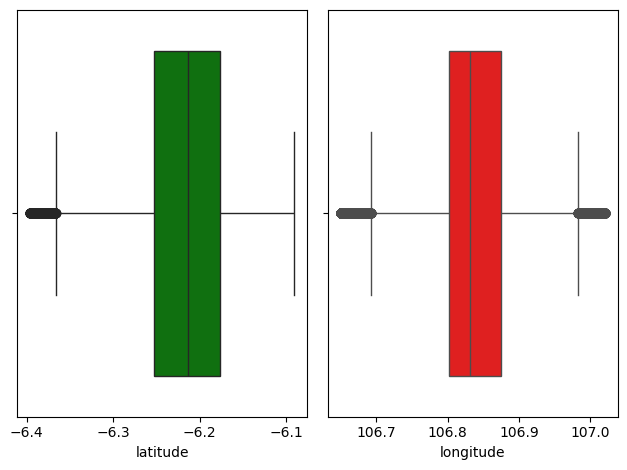

In [10]:
# batas geofencing operasional November 2019
LAT_MIN, LAT_MAX = -6.400, -6.050
LON_MIN, LON_MAX = 106.650, 107.020

# filter data yang hanya berada di dalam batas geofencing ini
df_clean_geo = df_clean_over_speed.loc[
    (df_clean_over_speed["latitude"] >= LAT_MIN) & (df_clean_over_speed["latitude"] <= LAT_MAX) &
    (df_clean_over_speed["longitude"] >= LON_MIN) & (df_clean_over_speed["longitude"] <= LON_MAX)
]

data_terbuang = df_clean_over_speed.shape[0] - df_clean_geo.shape[0]
print(f"{data_terbuang} data terbuang")
print(df_clean_geo.shape[0])

fig, axes = plt.subplots(1, 2)
sns.boxplot(ax=axes[0], x=df_clean_geo["latitude"], color="green")
sns.boxplot(ax=axes[1], x=df_clean_geo["longitude"], color="red")
plt.tight_layout()
plt.show()


**Insight**:

Pada tahap ini ditentukan batas geografis (geofencing) sesuai dengan wilayah operasional TJ per November 2019 untuk menghilangkan outlier yang sebelumnya ditemukan. Batas batasnya antara lain: -6.050 untuk batas maksimum latitude utara (daerah ujung Ancol Tanjung Priok, belum ada halte PIK), -6.4 batas maksimum latitude selatan (sekitar Cibubur, UI), 106.7 untuk batas maksimum longitude barat (daerah Kota Tangerang, Ciledug), 107 untuk batas maksimum longitude timur.

Dari proses ini diperoleh hasil 10.523 data yang terbuang, dengan persebaran data seperti pada boxplot. Titik titik outlier diluar whisker bukan merupakan outlier melainkan bus dengan rute terjauh yang dapat dijangkau dalam wilayah geofencing yang telah ditetapkan

### Distance-to-Destination Anomaly

In [11]:
mask_zero_dtd = df_clean_geo['dtd'] == 0 
print(df_clean_geo[mask_zero_dtd].shape[0])
df_clean_geo.loc[mask_zero_dtd, ["speed", "location"]].head(n=20)

517647


,speed,location
0,0.0,NaN
1,0.0,NaN
2,0.0,NaN
3,0.0,NaN
4,0.0,NaN
5,0.0,NaN
6,0.0,NaN
7,0.0,NaN
8,0.0,NaN
9,0.0,NaN


**Insight**:

Pada tahap ini, baris dtd yang bernilai 0 akan diproses. Sebelumnya perlu diketahui bahwa dtd yang bernilai 0 secara konsisten memiliki data location yang kosong. Bukan karena busnya sudah sampai di halte tujuan, melainkan kesalahan sistem (data artefak) di mana perangkat GPS bus belum berhasil mengunci (lock) segmen rute (misal 13-2 menuju 13-1). Akibatnya, meskipun bus terdeteksi sedang bergerak aktif dengan kecepatan sangat rendah, sistem belum mampu memetakan posisi bus tersebut ke segmen halte manapun. Data pada kondisi ini tidak mencerminkan situasi operasional yang valid dan sebaiknya dieliminasi.  

In [12]:
df_clean_zero_dtd = df_clean_geo[df_clean_geo['dtd'] > 0].copy()
print(df_clean_zero_dtd[(df_clean_zero_dtd['location'].isna()) & (df_clean_zero_dtd['dtd'] == 0.5)].shape[0])
print(df_clean_zero_dtd[df_clean_zero_dtd['dtd'] == 0.5]['location'].isna().mean())
df_clean_zero_dtd[df_clean_zero_dtd['location'].isna()][['dtd', 'speed', 'location']].sample(10)

12602
1.0


,dtd,speed,location
372424,0.5,0.0,NaN
9140,0.5,19.0,NaN
496105,0.5,0.0,NaN
187517,0.5,1.1,NaN
224123,0.5,6.1,NaN
148454,0.5,9.9,NaN
215971,0.5,0.0,NaN
334760,0.5,0.0,NaN
455015,0.5,26.9,NaN
451829,0.5,7.4,NaN


**Insight:**

Setelah baris dengan dtd bernilai 0 dihilangkan, muncul inkonsistensi baru. Asumsi dengan menghilangkan dtd bernilai 0 akan menghapus baris dengan location yang kosong namun nyatanya ada pola konsisten di mana baris dengan location kosong memiliki dtd yang konsisten di angka 0.5. Nilai 0.5 ini kemungkinan adalah default placeholder yang ditetapkan di sistem GPS TJ saat bus baru memulai trip atau keluar terminal sebelum sistem berhasil lock ke segmen halte pertama. Jadi bukan nilai operasional real, melainkan inisialisasi sistem.

In [13]:
df_clean_empty_loc = df_clean_zero_dtd[~(df_clean_zero_dtd['location'].isna())].copy()
print(f"{df_clean_zero_dtd.shape[0] - df_clean_empty_loc.shape[0]} data terbuang")
print(df_clean_empty_loc.shape)
print(df_clean_empty_loc['location'].isna().sum())

12602 data terbuang
(234476, 11)
0


In [14]:
print(df.shape[0] - df_clean_empty_loc.shape[0])
print(df_clean_empty_loc['corridor'].nunique())
print(df_clean_empty_loc['bus_code'].nunique())
print(df_clean_empty_loc['gps_datetime'].min(), df_clean_empty_loc['gps_datetime'].max())

print(df_clean_empty_loc['trip_id'].nunique())

540982
18
1002
2019-11-26 14:00:00 2019-11-26 17:59:59
250


In [15]:
df_clean_empty_loc.describe()

,dtd,longitude,latitude,speed,course
count,234476.000000,234476.000000,234476.000000,234476.000000,234476.000000
mean,0.511817,106.833233,-6.204007,14.015310,195.565572
std,0.342824,0.043638,0.048597,15.529659,103.038274
min,0.000228,106.705400,-6.310175,0.000000,0.000000
25%,0.164434,106.808892,-6.238930,0.000000,103.000000
50%,0.526440,106.829430,-6.200016,6.900000,189.000000
75%,0.851039,106.869209,-6.166223,27.000000,277.000000
max,1.000000,106.949509,-6.109158,78.400000,360.000000


**Insight**:

Setelah membersihkan 540.981 baris, cek ulang apakah representasi data tetap aman. Hasilnya dapat dilihat masih cukup representatif dengan 18 koridor, 1002 bus unik, rentang waktu penuh 14.00–18.00 terjaga sehingga representasi dataset tidak hilang. Selain itu, penyebaran dtd kini lebih baik dengan Q1-Q3 yang tidak menumpuk di 0, serta longitude dan speed yang sudah sesuai dengan batas yang benar

In [16]:
df_clean_empty_loc.sample(10) 

,bus_code,trip_id,gps_datetime,location,dtd,corridor,longitude,latitude,speed,course,color
490318,SAF 054,3.F004,2019-11-26 16:07:56,"3-5,3-4",0.031652,3,106.730427,-6.154863,0.2,276,BIRU PUTIH
513812,SAF 109,8.001,2019-11-26 14:10:35,"8-10,8-11",0.926590,8,106.772465,-6.213440,46.8,333,BIRU PUTIH
91263,KAJ 233,11.Q001,2019-11-26 17:16:14,"11-1,11-2",0.786493,11,106.946700,-6.212300,32.0,254,BIRU PUTIH
608905,TJ 0471,13.A011,2019-11-26 14:26:12,"13-1,13-2",0.041103,13,106.830535,-6.240395,0.3,269,BIRU PUTIH
406163,PPD 0612,4.C001,2019-11-26 15:05:14,"4-2,4-3",0.992025,4,106.905000,-6.192383,0.0,252,BIRU KOMBINASI
476803,SAF 022,9.002,2019-11-26 14:20:09,"9-27,9-26",0.906664,9,106.792133,-6.125305,0.8,181,BIRU PUTIH
491900,SAF 058,10.D002,2019-11-26 14:38:42,"10-6,10-7",0.742667,10,106.884483,-6.157040,52.7,220,BIRU PUTIH
227099,MYS 19222,7.A006,2019-11-26 14:47:54,"7-1,7-2",0.074782,7A,106.882120,-6.309693,0.1,327,BIRU
188702,MYS 18125,3.006,2019-11-26 14:54:30,"1-15,2-19",0.129164,3,106.820740,-6.166915,0.3,161,BIRU
193582,MYS 18137,3.010,2019-11-26 15:24:44,"3-1,3-2",0.170414,3,106.707145,-6.155747,31.5,90,BIRU


### Set gps_datetime Data Type

In [22]:
df_clean_empty_loc['gps_datetime'] = pd.to_datetime(df_clean_empty_loc['gps_datetime'])
df_clean_empty_loc['hour'] = df_clean_empty_loc['gps_datetime'].dt.hour
df_clean_empty_loc['day_of_week'] = df_clean_empty_loc['gps_datetime'].dt.dayofweek

df_clean_empty_loc.info()
df_clean_empty_loc.sample(5)

<class 'pandas.DataFrame'>
Index: 234476 entries, 15 to 774869
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   bus_code      234476 non-null  str           
 1   trip_id       234476 non-null  str           
 2   gps_datetime  234476 non-null  datetime64[us]
 3   location      234476 non-null  str           
 4   dtd           234476 non-null  float64       
 5   corridor      234476 non-null  str           
 6   longitude     234476 non-null  float64       
 7   latitude      234476 non-null  float64       
 8   speed         234476 non-null  float64       
 9   course        234476 non-null  int64         
 10  color         211825 non-null  str           
 11  hour          234476 non-null  int32         
 12  day_of_week   234476 non-null  int32         
dtypes: datetime64[us](1), float64(4), int32(2), int64(1), str(5)
memory usage: 23.3 MB


,bus_code,trip_id,gps_datetime,location,dtd,corridor,longitude,latitude,speed,course,color,hour,day_of_week
478209,SAF 025,10.001,2019-11-26 15:45:37,"10-18,10-17",0.155369,10,106.877918,-6.238127,27.1,335,BIRU PUTIH,15,1
303113,PPD 0265,2.B003,2019-11-26 16:18:57,"2-1,2-2",0.529117,2,106.903893,-6.179600,0.0,288,BIRU KOMBINASI,16,1
259387,PPD 0160,9.002,2019-11-26 17:16:40,"7-10,7-9",0.137823,9,106.872749,-6.246030,0.0,96,BIRU KOMBINASI,17,1
494048,SAF 062,1.204,2019-11-26 17:41:49,"1-15,1-14",0.968878,1,106.822820,-6.175928,0.4,183,BIRU PUTIH,17,1
488939,SAF 051,5.C031,2019-11-26 15:57:21,"7-13,5-18",0.920154,7,106.866693,-6.225095,16.9,335,BIRU PUTIH,15,1


**Insight**:

Proses selanjutnya adalah mengubah tipe data gps_datetime menjadi dalam bentuk datetime64[us] dari yang sebelumnya berupa string. Setelahnya, datetime diekstrak jam dan harinya menjadi kolom hour untuk mendefinisikan jam dalam format 24 hour dan day_of_week untuk mendefinisikan hari, nantinya akan digunakan dalam tahap feature engineering 

### Drop Duplicates

In [30]:
print(df_clean_empty_loc.duplicated().sum())
df_clean_empty_loc[df_clean_empty_loc.duplicated(subset=['bus_code', 'gps_datetime'], keep=False)][
    ['bus_code', 'gps_datetime', 'speed', 'location', 'dtd']
].sort_values(['bus_code', 'gps_datetime']).head(20)

8209


,bus_code,gps_datetime,speed,location,dtd
33,DMR 5049,2019-11-26 14:16:49,0.0,"5-12,5-11",0.064937
34,DMR 5049,2019-11-26 14:16:49,0.0,"5-12,5-11",0.064937
39,DMR 5049,2019-11-26 14:19:54,29.0,"5-11,5-10",0.887694
40,DMR 5049,2019-11-26 14:19:54,29.0,"5-11,5-10",0.887694
49,DMR 5049,2019-11-26 14:24:49,30.0,"5-8,5-7",0.545256
50,DMR 5049,2019-11-26 14:24:49,30.0,"5-8,5-7",0.545256
51,DMR 5049,2019-11-26 14:24:49,30.0,"5-8,5-7",0.545256
52,DMR 5049,2019-11-26 14:24:49,30.0,"5-8,5-7",0.545256
95,DMR 5049,2019-11-26 14:48:05,14.0,"5-4,5-3",0.964137
96,DMR 5049,2019-11-26 14:48:05,14.0,"5-4,5-3",0.964137


In [34]:
df_clean_dupes = df_clean_empty_loc.drop_duplicates(subset=['bus_code', 'gps_datetime']).copy()
print(df_clean_dupes.shape)

print("Data duplikat:", df_clean_dupes.duplicated().sum())

(226231, 13)
Data duplikat: 0


**Insight**:

Setelah diperiksa ulang, masih terdapat data terduplikasi sebanyak 8209 baris. Data yang duplikat tersebut bukan kondisi operasional berulang seperti log berulang saat kondisi lampu merah atau macet parah, tapi data yang benar-benar terduplikasi di sumber. Dapat dilihat bahwa semua kolom identik termasuk timestamp. 

### Corridor Anomaly

In [37]:
print(df_clean_dupes['corridor'].value_counts())

df_cleaned = df_clean_dupes[df_clean_dupes['corridor'] != '0'].copy()
print(df_cleaned.shape)

(df_cleaned['corridor'] == '0').value_counts()

corridor
1     31908
9     28688
6     22062
10    18069
5     17360
2     15547
8     15287
4     15118
3     13883
7     12703
13    12511
12    10502
11     7919
7B     1871
7A     1815
8A      742
3A      245
0         1
Name: count, dtype: int64
(226230, 13)


corridor
False    226230
Name: count, dtype: int64

**Insight**:

Setelah diperiksa ulang, masih terdapat anomali yakni baris dengan koridor 0 yang tidak valid dengan koridor resmi TJ. Setelah data anomali tersebut dibuang, didapatkan hasil akhir dataset bersih dengan baris sebanyak **226.230** dan kolom sebanyak **13**